In [ ]:
!pip install pandas numpy matplotlib seaborn folium scikit-learn geopy ipywidgets


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import folium
from geopy.distance import geodesic
import ipywidgets as widgets
from IPython.display import display, clear_output


# Inference Attacks: Temporal and Spatial Analysis
 We begin by analyzing query patterns to infer potential home, work, and interest locations for users. This includes exploring time-of-day behavior and types of queried POIs.


In [3]:
# Load of the dataset/queries
df = pd.read_csv("privacy_evaluation/queries.csv", sep=' ')
df['hour'] = df['timestamp'] % 24

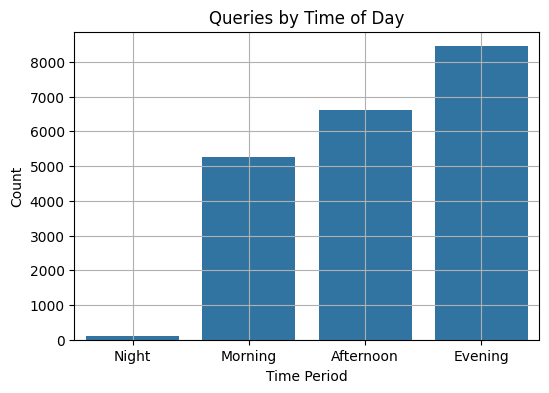

In [4]:
# Distribution of requests by time of the day
df['time_block'] = pd.cut(df['hour'], bins=[0, 6, 12, 18, 24], labels=["Night", "Morning", "Afternoon", "Evening"])
time_dist = df['time_block'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=time_dist.index, y=time_dist.values)
plt.title("Queries by Time of Day")
plt.xlabel("Time Period")
plt.ylabel("Count")
plt.grid(True)
plt.show()

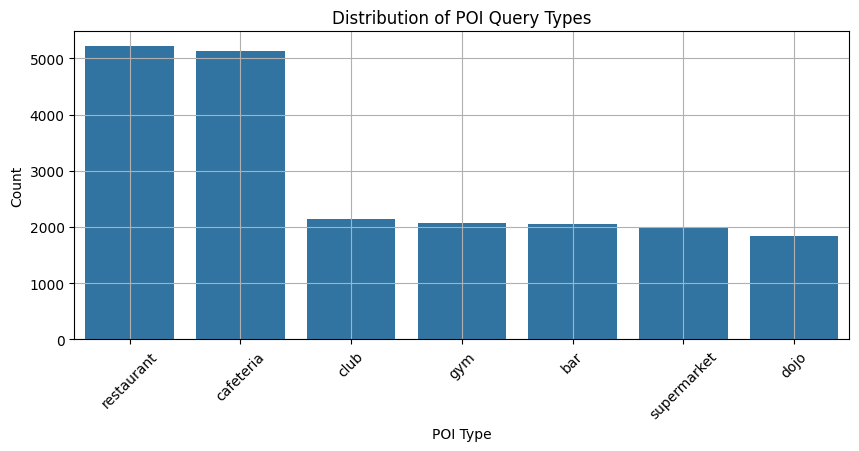

In [5]:
# Most visited POIs
poi_counts = df['poi_type_query'].value_counts()

plt.figure(figsize=(10, 4))
sns.barplot(x=poi_counts.index, y=poi_counts.values)
plt.xticks(rotation=45)
plt.title("Distribution of POI Query Types")
plt.xlabel("POI Type")
plt.ylabel("Count")
plt.grid(True)
plt.show()

To infer work locations, we isolate queries made during standard working hours (9 AM to 5 PM), assuming repeated visits to similar coordinates in that range indicate a workplace.


In [6]:
# Filter requests during work hours
work_hours = df[(df['hour'] >= 9) & (df['hour'] <= 17)]

# Extract coordinates for clustering
work_locations = work_hours[['lat', 'lon']].to_numpy()

In [7]:
# Clustering function with K-means
def plot_clusters(k):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(work_locations)
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    plt.figure(figsize=(8, 6))
    plt.scatter(work_locations[:, 0], work_locations[:, 1], c=labels, cmap='tab10', s=10)
    plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='x', label='Centroids')
    plt.title(f"KMeans Clustering (k={k})")
    plt.xlabel("Latitude")
    plt.ylabel("Longitude")
    plt.legend()
    plt.grid(True)
    plt.show()


In [8]:
# Interactive widget to choose k
slider = widgets.IntSlider(value=3, min=1, max=15, step=1, description="k:")
widgets.interactive(plot_clusters, k=slider)

interactive(children=(IntSlider(value=3, description='k:', max=15, min=1), Output()), _dom_classes=('widget-in…

In [9]:
def display_ip_map(ip):
    sub = df[df["ip_address"] == ip]
    m = folium.Map(location=[sub['lat'].mean(), sub['lon'].mean()], zoom_start=13)

    poi_colors = {
        "restaurant": "red",
        "club": "pink",
        "bar": "purple",
        "cafeteria": "darkred",
        "dojo": "darkgreen",
        "supermarket": "orange",
        "gym": "green"
    }

    for _, row in sub.iterrows():
        folium.Marker(
            location=[row["lat"], row["lon"]],
            popup=row["poi_type_query"],
            icon=folium.Icon(color=poi_colors.get(row["poi_type_query"], "blue"))
        ).add_to(m)

    legend_html = """
    <div style="position: fixed;
                bottom: 20px; left: 20px; width: 200px; height: auto;
                background-color: white; z-index:9999; font-size:14px;
                border:1px solid grey; padding:10px;">
    <i style="color:red;">■</i> Restaurant<br>
    <i style="color:pink;">■</i> Club<br>
    <i style="color:purple;">■</i> Bar<br>
    <i style="color:darkred;">■</i> Cafeteria<br>
    <i style="color:darkgreen;">■</i> Dojo<br>
    <i style="color:orange;">■</i> Supermarket<br>
    <i style="color:green;">■</i> Gym<br>
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))

    return m


# Example for the first IP
first_ip = df["ip_address"].iloc[0]
display_ip_map(first_ip)


In [10]:
# Calculate spatial k-anonimity
# For each request, we count how many other requests from the same user are in a radius of 500m
def compute_k_anonymity(query_row, group_df, radius_km=0.5):
    origin = (query_row['lat'], query_row['lon'])
    distances = group_df.apply(lambda r: geodesic(origin, (r['lat'], r['lon'])).km, axis=1)
    return np.sum(distances <= radius_km)

# To limit number of computations, we take only the 1000 first requests
eval_subset = df.head(1000).copy()

eval_subset['k_anonymity'] = eval_subset.apply(
    lambda row: compute_k_anonymity(row, eval_subset[eval_subset['ip_address'] == row['ip_address']]),
    axis=1
)



In [11]:
# Display requests with low anonimity (k<5)
low_k = eval_subset[eval_subset['k_anonymity'] < 5]
print("Queries with low spatial anonymity (k < 5):")
display(low_k[['ip_address', 'lat', 'lon', 'k_anonymity']])


Queries with low spatial anonymity (k < 5):


,ip_address,lat,lon,k_anonymity
27,34.101.177.245,46.525804,6.579522,1
28,34.101.177.245,46.522058,6.575245,2
29,34.101.177.245,46.534388,6.620946,1
32,34.101.177.245,46.552574,6.558614,1
62,34.101.177.245,46.533873,6.562580,2
63,34.101.177.245,46.530298,6.561513,2
66,34.101.177.245,46.509527,6.642144,2
67,34.101.177.245,46.510799,6.643288,2
100,34.101.177.245,46.520562,6.577343,2
101,34.101.177.245,46.514210,6.577225,1


---
# Privacy Defence Strategy

Having demonstrated that user queries can leak sensitive location information through spatial and temporal patterns, we now implement a defence. Our goal is to increase $k$-anonymity by injecting dummy queries around vulnerable real ones.

This aims to protect user privacy by making it harder for an adversary to distinguish isolated, traceable queries.


In [12]:
# Generation of dummy queries
def generate_dummy_queries(df_sensitive, target_k=8, radius_km=0.5):
    dummy_data = []
    for _, row in df_sensitive.iterrows():
        missing = target_k - row['k_anonymity']
        for _ in range(missing):
            lat_offset = np.random.normal(0, radius_km / 111)  # ~1° ≈ 111km
            lon_offset = np.random.normal(0, radius_km / 111)
            dummy_data.append({
                'ip_address': row['ip_address'],
                'lat': row['lat'] + lat_offset,
                'lon': row['lon'] + lon_offset,
                'timestamp': row['timestamp'],
                'poi_type_query': row['poi_type_query'],
                'is_dummy': True
            })
    return pd.DataFrame(dummy_data)

dummy_df = generate_dummy_queries(low_k)

In [13]:
# merge of real data and dummies
eval_subset['is_dummy'] = False
full_data = pd.concat([eval_subset, dummy_df], ignore_index=True)

In [14]:
# Recalculation of the k-anonimity
real_data = full_data[~full_data['is_dummy']].copy()

real_data.loc[:, 'k_anonymity'] = real_data.apply(
    lambda row: compute_k_anonymity(row, full_data[full_data['ip_address'] == row['ip_address']]),
    axis=1
)

before = (eval_subset['k_anonymity'] < 5).mean()
after = (real_data['k_anonymity'] < 5).mean()

print(f"🔴 Before defense: {before:.2%} of queries had k < 5")
print(f"🟢 After defense:  {after:.2%} of queries had k < 5")

🔴 Before defense: 4.40% of queries had k < 5
🟢 After defense:  0.80% of queries had k < 5


In [15]:
# Map visualization (real vs dummy)
def map_real_vs_dummy(ip):
    subset = full_data[full_data['ip_address'] == ip]
    m = folium.Map(location=[subset['lat'].mean(), subset['lon'].mean()], zoom_start=13)

    for _, row in subset.iterrows():
        color = 'blue' if row.get('is_dummy', False) else 'green'
        popup = "Dummy" if row.get('is_dummy', False) else "Real"
        folium.Marker(
            location=[row['lat'], row['lon']],
            popup=popup,
            icon=folium.Icon(color=color)
        ).add_to(m)

    legend_html = """
    <div style="position: fixed;
                bottom: 20px; left: 20px; width: 180px; height: auto;
                background-color: white; z-index:9999; font-size:14px;
                border:1px solid grey; padding:10px;">
    <b>Query Type</b><br>
    <i style="color:green;">■</i> Real Query<br>
    <i style="color:blue;">■</i> Dummy Query<br>
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))

    return m

# Example IP
example_ip = full_data['ip_address'].iloc[0]
map_real_vs_dummy(example_ip)
